# Задание 3 — Аномалии и отказы оборудования


In [1]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy import stats
from sklearn.ensemble import IsolationForest

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)

## 1. Загрузка данных


In [2]:
sensors_df  = read_parquet(BUCKET, 'pump_sensors/pump_sensors.parquet')
failures_df = read_parquet(BUCKET, 'pump_failures/pump_failures.parquet')
pumps_df    = read_parquet(BUCKET, 'pumps/pumps.parquet')

sensors_df['timestamp']       = pd.to_datetime(sensors_df['timestamp'])
failures_df['failure_date']   = pd.to_datetime(failures_df['failure_date'])

print(f'pump_sensors:  {sensors_df.shape}')
print(f'pump_failures: {failures_df.shape}')
print(f'pumps:         {pumps_df.shape}')
display(sensors_df.head())

pump_sensors:  (72, 8)
pump_failures: (3, 5)
pumps:         (5, 6)


,record_id,pump_id,timestamp,temperature,vibration,current,rpm,pressure
0,1,1,2025-10-01 00:00:00,72.3,2.1,58.2,1470.0,122.4
1,2,1,2025-10-01 03:00:00,72.6,2.0,58.4,1472.0,122.5
2,3,1,2025-10-01 06:00:00,73.1,2.2,58.6,1474.0,122.6
3,4,1,2025-10-01 09:00:00,72.8,2.1,58.3,1471.0,122.3
4,5,1,2025-10-01 12:00:00,73.0,2.3,58.5,1473.0,122.7


## 2. Z-score аномалии


In [3]:
SENSOR_COLS = ['temperature', 'vibration', 'current', 'rpm', 'pressure']
Z_THRESHOLD = 3.0

for col in SENSOR_COLS:
    sensors_df[f'z_{col}'] = np.abs(stats.zscore(sensors_df[col].fillna(sensors_df[col].mean())))

sensors_df['z_anomaly'] = (sensors_df[[f'z_{c}' for c in SENSOR_COLS]] > Z_THRESHOLD).any(axis=1).astype(int)
print(f'Z-score anomalies: {sensors_df["z_anomaly"].sum()} of {len(sensors_df)}')

Z-score anomalies: 2 of 72


## 3. Isolation Forest


In [4]:
X = sensors_df[SENSOR_COLS].fillna(sensors_df[SENSOR_COLS].mean())

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
sensors_df['if_label']   = iso.fit_predict(X)
sensors_df['if_anomaly'] = (sensors_df['if_label'] == -1).astype(int)

print(f'IsolationForest anomalies: {sensors_df["if_anomaly"].sum()} of {len(sensors_df)}')

IsolationForest anomalies: 4 of 72


## 4. Risk Score


In [5]:
sensors_df['risk_score'] = sensors_df['z_anomaly'] + sensors_df['if_anomaly']

pump_risk = (
    sensors_df.groupby('pump_id')
    .agg(avg_risk=('risk_score', 'mean'), max_risk=('risk_score', 'max'), total_anomalies=('if_anomaly', 'sum'))
    .reset_index()
    .sort_values('avg_risk', ascending=False)
)
display(pump_risk)

,pump_id,avg_risk,max_risk,total_anomalies
2,5,0.208333,2,3
0,1,0.041667,1,1
1,3,0.000000,0,0


## 5. График 1 — Аномалии по времени


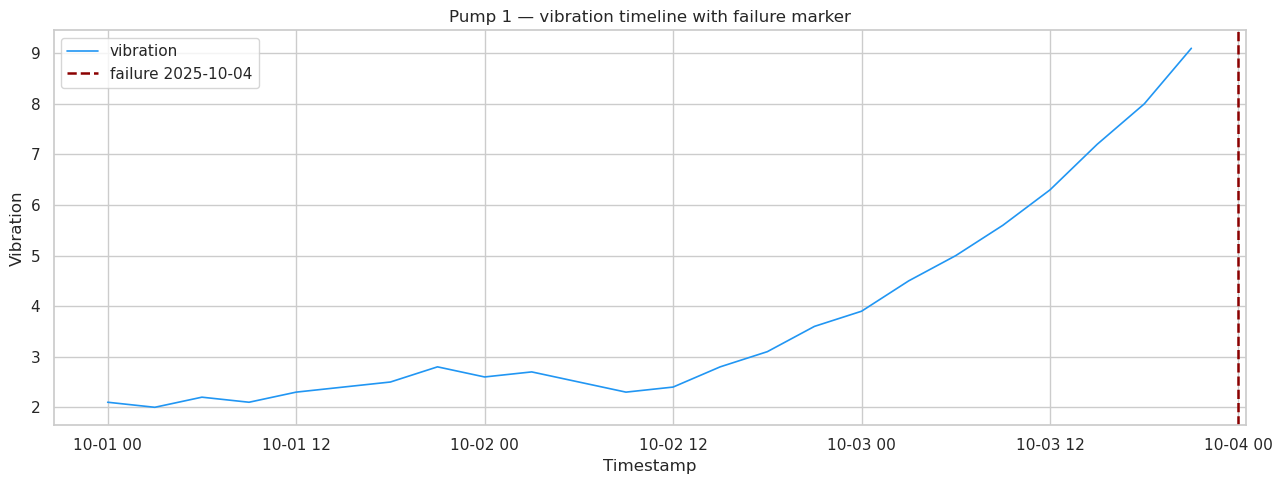

In [6]:
s = sensors_df[sensors_df['pump_id'] == 1].sort_values('timestamp')
failure_line = pd.Timestamp('2025-10-04')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(s['timestamp'], s['vibration'], color='#2196F3', linewidth=1.2, label='vibration')
ax.axvline(failure_line, color='darkred', linestyle='--', linewidth=1.8, label='failure 2025-10-04')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Vibration')
ax.set_title('Pump 1 — vibration timeline with failure marker')
ax.legend()
plt.tight_layout()
plt.show()

## 6. График 2 — Box plot: вибрация normal vs anomaly


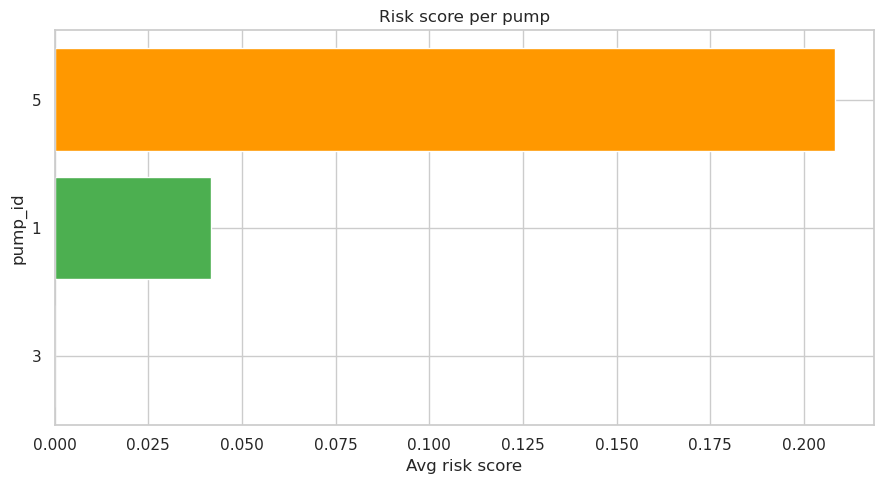

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
pump_risk_sorted = pump_risk.sort_values('avg_risk', ascending=True)
colors = ['#F44336' if r > 0.5 else '#FF9800' if r > 0.1 else '#4CAF50' for r in pump_risk_sorted['avg_risk']]
ax.barh(pump_risk_sorted['pump_id'].astype(str), pump_risk_sorted['avg_risk'], color=colors)
ax.set_title('Risk score per pump')
ax.set_xlabel('Avg risk score')
ax.set_ylabel('pump_id')
plt.tight_layout()
plt.show()

## 7. Паттерны перед отказом


## 8. Сохранение в PostgreSQL


In [8]:
cols_to_save = ['pump_id', 'timestamp', 'temperature', 'vibration', 'current', 'rpm', 'pressure',
                'z_anomaly', 'if_anomaly', 'risk_score']
sensors_df[cols_to_save].to_sql('analytics_anomalies', engine, if_exists='replace', index=False)
print(f'Saved {len(sensors_df)} rows to analytics_anomalies')

Saved 72 rows to analytics_anomalies
